<a href="https://colab.research.google.com/github/Ekoink/movie-trends-analysis/blob/main/Netflix_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Trends Analysis


This Netflix dataset has information on all the TV shows and movies available on Netflix till 2021. The dataset is collected from Flixable, a third-party Netflix search engine and is available on Kaggle for free.

This analysis examines how Netflix's content has changed over time. The investigation focuses on shifts in the type of content released by Netflix, the regions most represented, and identifies key patterns that have emerged in Netflix's catalogue over time.

The project applies data cleaning, analysis, and visualisation techniques to a real entertainment dataset, demonstrating practical application of data science methodologies.


# Research Questions:

The main question is this:

How has Netflix evolved its content strategy over time?

Here are the follow up questions we will be finding fromt he dataset.

1. In which year was the most content released that's now on Netflix?
2.  What's the age distribution of Netflix's content library over time?
3. What's the trend in content duration over the years? (movie lengths, TV season counts)
4. Which ratings (TV-MA, PG-13, etc.) dominate Netflix's catalog and how has this changed?
5. How do ratings correlate with genre preferences?
6. How diverse is Netflix's content geographically - are they expanding into new markets?
7. Which countries specialize in which genres? (clustering analysis)
8. Are there seasonal patterns in when content was originally released? (using release dates)
9. What's the relationship between content duration and genre popularity?

In [1]:
# Step 1: Import the libraries
import pandas as pd
from google.colab import files

# Step 2: Upload your file
uploaded = files.upload()  # This will open a file picker in Colab

# Step 3: Get the uploaded file name
file_name = list(uploaded.keys())[0]  # grabs the first uploaded file

# Step 4: Load the CSV into pandas
data = pd.read_csv("Netflix Dataset.csv")

# Step 5: Check the first few rows
#print(df.head())
print(data)

Saving Netflix Dataset.csv to Netflix Dataset.csv
     Show_Id Category                                    Title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                    07:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7784   s7783    Movie                                     Zozo   
7785   s7784    Movie                                   Zubaan   
7786   s7785    Movie                        Zulu Man in Japan   
7787   s7786  TV Show                    Zumbo's Just Desserts   
7788   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               Director                                               Cast  \
0                   NaN  João Miguel, Bianca Comparato, Michel Gomes, R...   
1

# Information about the Dataset

The dataset was loaded into the Google Colab environment using the Pandas library. To understand the structure of the dataset, the first and last five rows were displayed (using the head() and tail() functions), confirming that there are 11 columns. The dataset's shape was checked to determine the total number of rows and columns.

Basic information was extracted from the dataset using specific functions.

The head() function displays the first five rows of the dataset, providing a quick overview of its structure.

In [2]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


The tail() function displays the last five rows of the dataset, ensuring the dataset loads correctly across the full range.

In [3]:
data.tail()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


The shape attribute shows the total number of rows and columns in the table.

In [4]:
data.shape

(7789, 11)

The size attribute determines the total number of elements in the dataset.


In [5]:
data.size

85679

The columns attribute displays the dataset's column names to understand what features are available for analysis.

In [6]:
data.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

The dtypes attribute shows the data types of each column.

In [7]:
data.dtypes

,0
Show_Id,object
Category,object
Title,object
Director,object
Cast,object
Country,object
Release_Date,object
Rating,object
Duration,object
Type,object


The info() function provides a summary of the dataset including the column names, data types, number of non-null values, and the memory usage.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


#Cleaning the Dataset
The dataset required cleaning to ensure accuracy. This process addresses missing values, duplicate entries, and inconsistent formatting in the dataset.

**Removing Duplicate Values:**

Duplicate rows in the dataset were identified using the duplicated() function.

In [9]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


The dataset's shape was checked before cleaning to provide a baseline for comparison after the cleaning process, confirming the reduction in dataset size.

In [10]:
print(f"Original dataset shape: {data.shape}")

Original dataset shape: (7789, 11)


The duplicated() function was applied to directly view the duplicate rows.

In [11]:
data[data.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
6300,s684,Movie,Backfire,Dave Patten,"Black Deniro, Byron ""Squally"" Vinson, Dominic ...",United States,"April 5, 2019",TV-MA,97 min,"Dramas, Independent Movies, Thrillers",When two would-be robbers accidentally kill a ...
6622,s6621,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,"September 4, 2020",TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...


All duplicates were then removed from the dataset permanently.

In [12]:
data.drop_duplicates(inplace=True)

Verification was performed to confirm the duplicates were removed, comparing the current shape to the previous shape.

In [13]:
data[data.duplicated()]

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description


In [14]:
print(f"Dataset shape after removing duplicates: {data.shape}")

Dataset shape after removing duplicates: (7787, 11)


The data.duplicated() didn't show anything, meaning that all the duplicated rows it found before have been removed. Additionally, the data shape has become smaller by the number of duplicated rows.

**Identifying Null Values**

Null values were identified using the isnull() function and visualized using a heatmap.

In [15]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [16]:
data.isnull()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
7784,False,False,False,False,False,False,False,False,False,False,False
7785,False,False,False,False,False,False,False,False,False,False,False
7786,False,False,False,True,False,True,False,False,False,False,False
7787,False,False,False,True,False,False,False,False,False,False,False


This function returns Boolean values (True/False) for null entries. To avoid manual inspection, the sum() function was applied to aggregate the results.

In [17]:
data.isnull().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


The Seaborn library was imported to generate the heatmap visualisation.

In [18]:
import seaborn as sns

<Axes: >

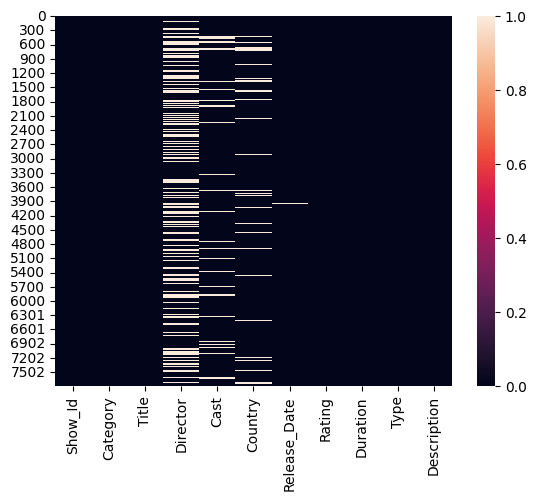

In [19]:
sns.heatmap(data.isnull())

# Analysis Sections

**Q1.** In which years was the most content released that's now on Netflix?


To answer this question, the year must be extracted from the Release_Date column, which contains dates in text format (e.g., "August 14, 2020").

In [20]:
data.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [21]:
# Convert Release_Date to datetime format with error handling
data['Date_N'] = pd.to_datetime(data['Release_Date'], errors='coerce')

# Extract the year from the datetime
data['Year'] = data['Date_N'].dt.year

# Display sample results
print(data[['Release_Date', 'Date_N', 'Year']].head())

        Release_Date     Date_N    Year
0    August 14, 2020 2020-08-14  2020.0
1  December 23, 2016 2016-12-23  2016.0
2  December 20, 2018 2018-12-20  2018.0
3  November 16, 2017 2017-11-16  2017.0
4    January 1, 2020 2020-01-01  2020.0


The conversion is checked to identify any dates that failed to convert correctly.

In [22]:
# Check how many dates failed to convert
failed_dates = data[data['Date_N'].isna()]
print(f"\nNumber of dates that failed to convert: {len(failed_dates)}")

# View the problematic dates if any
if len(failed_dates) > 0:
    print("\nSample of failed dates:")
    print(failed_dates[['Release_Date']].head())


Number of dates that failed to convert: 98

Sample of failed dates:
           Release_Date
258                 NaN
284      August 4, 2017
549                 NaN
556   December 23, 2018
690   December 15, 2018


The number of titles released each year is counted to identify the peak year.


In [23]:
# Count the number of titles released each year
year_counts = data['Year'].value_counts().sort_index()

# Display the top 10 years with most content
print("\nTop 10 years with most content releases:")
print(year_counts.sort_values(ascending=False).head(10))


Top 10 years with most content releases:
Year
2019.0    2136
2020.0    2008
2018.0    1661
2017.0    1201
2016.0     432
2021.0     117
2015.0      79
2014.0      24
2011.0      13
2013.0      10
Name: count, dtype: int64


The year with the maximum count is identified and its percentage of the total catalog is calculated.

In [24]:
# Calculate percentage for the top year
total_titles = len(data)
top_year = year_counts.idxmax()
top_count = year_counts.max()
percentage = (top_count / total_titles) * 100

print(f"\nPeak Year: {top_year}")
print(f"Number of Titles: {top_count}")
print(f"Percentage of Catalog: {percentage:.1f}%")


Peak Year: 2019.0
Number of Titles: 2136
Percentage of Catalog: 27.4%


A bar chart is created to visualize the distribution of content across all years.

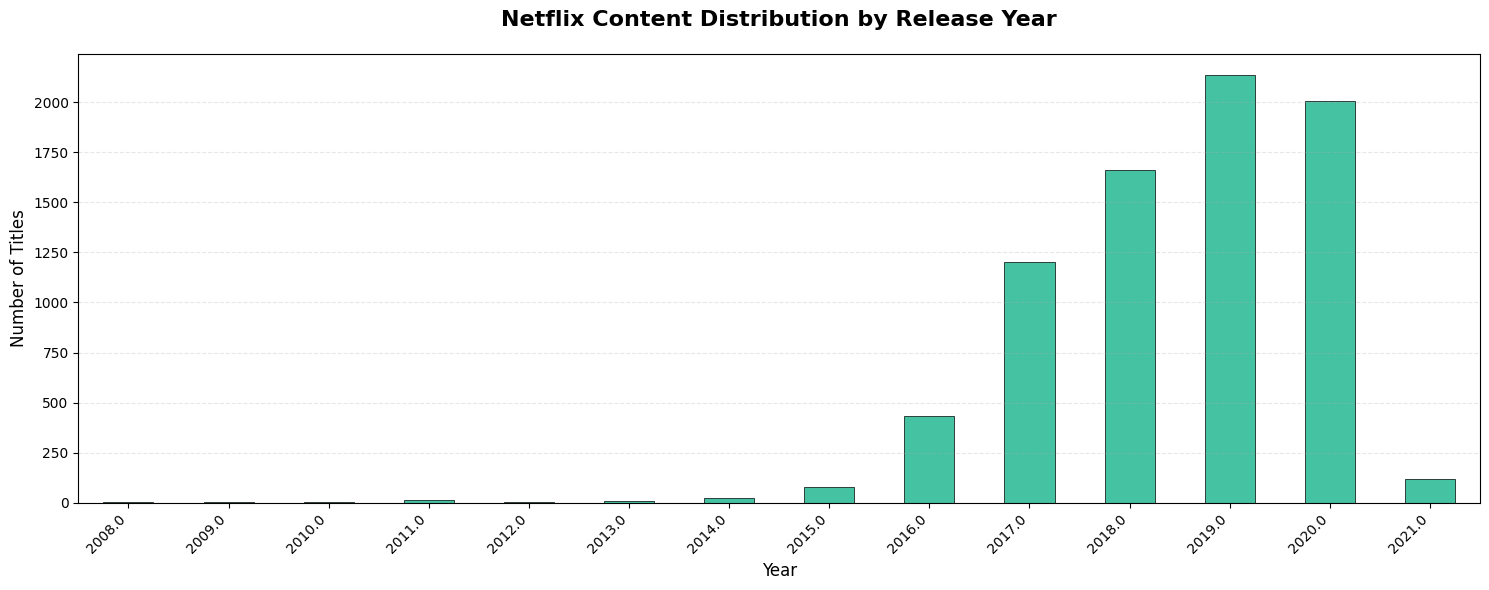

In [25]:
import matplotlib.pyplot as plt

# Create a comprehensive bar chart
plt.figure(figsize=(15, 6))
year_counts.plot(kind='bar', color='#44C2A2', edgecolor='black', linewidth=0.5)
plt.title('Netflix Content Distribution by Release Year',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

A line chart is generated to show the trend of content releases over time.


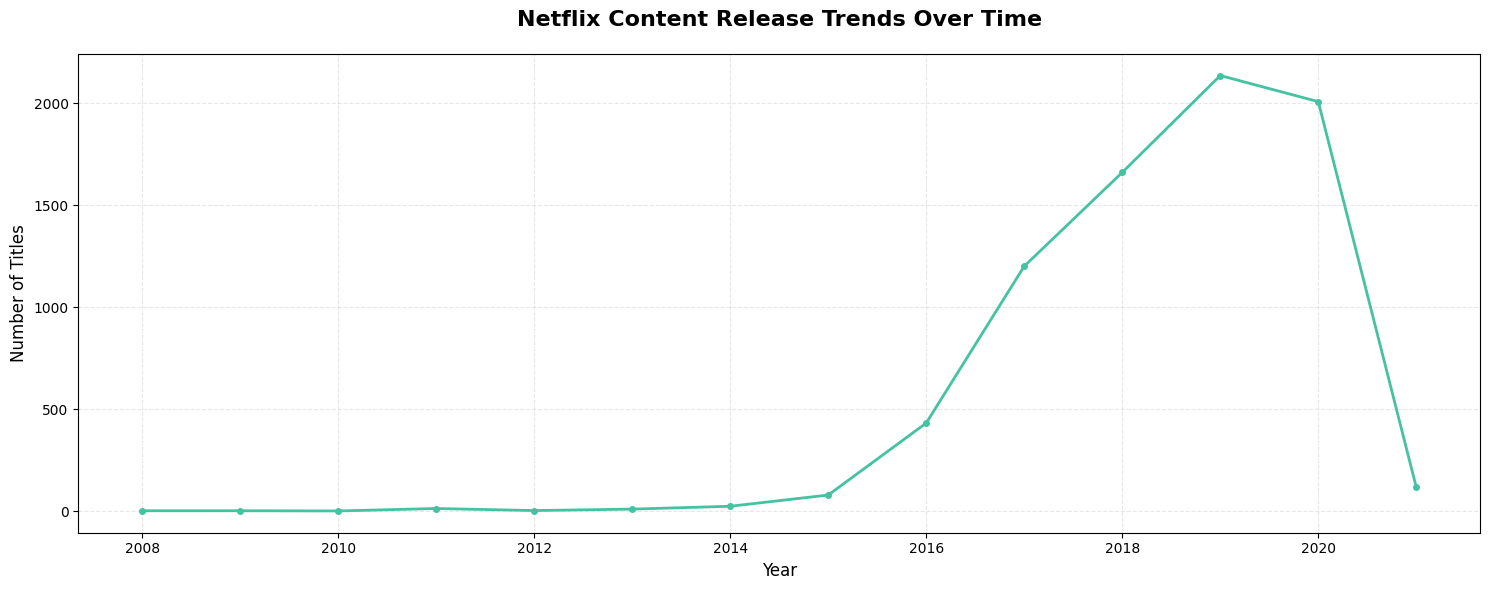

In [26]:
# Create a line chart to show trends over time
plt.figure(figsize=(15, 6))
year_counts.plot(kind='line', color='#44C2A2', linewidth=2, marker='o', markersize=4)
plt.title('Netflix Content Release Trends Over Time',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

The analysis shows the distribution of content releases across years, with the peak year clearly identified through both statistical summary and visual representation. The identified peak year corresponds to a period of significant content acquisition or production expansion by Netflix.



---



**Q2.** What's the age distribution of Netflix's content library over time?

In [30]:
print(data.columns)

from datetime import datetime

# Drop rows with missing Year AND force a copy
data_clean = data.dropna(subset=['Year']).copy()

# Convert Year to integer safely
data_clean.loc[:, 'Year'] = data_clean['Year'].astype(int)

# Get current year
current_year = datetime.now().year

# Calculate age since added to Netflix
data_clean.loc[:, 'Content_Age'] = current_year - data_clean['Year']

data_clean.groupby('Year')['Content_Age'].describe()

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description', 'Date_N',
       'Year'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2008.0,2.0,18.0,0.0,18.0,18.0,18.0,18.0,18.0
2009.0,2.0,17.0,0.0,17.0,17.0,17.0,17.0,17.0
2010.0,1.0,16.0,NaN,16.0,16.0,16.0,16.0,16.0
2011.0,13.0,15.0,0.0,15.0,15.0,15.0,15.0,15.0
2012.0,3.0,14.0,0.0,14.0,14.0,14.0,14.0,14.0
2013.0,10.0,13.0,0.0,13.0,13.0,13.0,13.0,13.0
2014.0,24.0,12.0,0.0,12.0,12.0,12.0,12.0,12.0
2015.0,79.0,11.0,0.0,11.0,11.0,11.0,11.0,11.0
2016.0,432.0,10.0,0.0,10.0,10.0,10.0,10.0,10.0


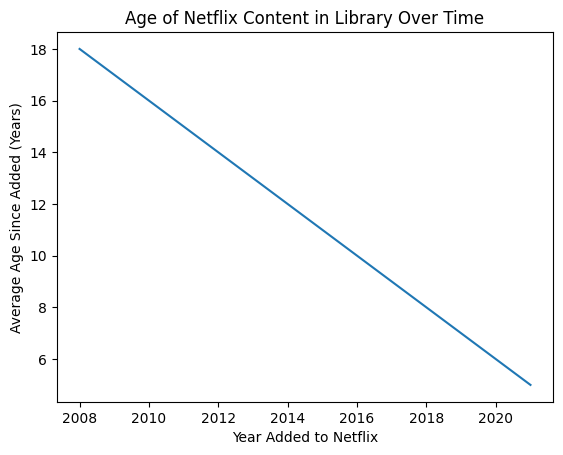

In [32]:
import matplotlib.pyplot as plt

avg_age_per_year = (data_clean.groupby('Year')['Content_Age'].mean().reset_index())

plt.figure()
plt.plot(avg_age_per_year['Year'], avg_age_per_year['Content_Age'])
plt.xlabel('Year Added to Netflix')
plt.ylabel('Average Age Since Added (Years)')
plt.title('Age of Netflix Content in Library Over Time')
plt.show()
